# Semana 3 — RFM y segmentación de clientes

Segmentación RFM de la base analítica de Olist y caracterización de los 6 segmentos de clientes (`marts.dim_cliente_segmento`).

## 1. Setup — conexión y carga de dim_cliente_segmento

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DB = "../olist.duckdb"

def q(sql):
    """Consulta de solo-lectura con conexión efímera: abre, lee y cierra al instante,
    para no dejar la base tomada por el kernel."""
    con = duckdb.connect(DB, read_only=True)
    try:
        return con.execute(sql).df()
    finally:
        con.close()


In [2]:
segmentos = q("select * from marts.dim_cliente_segmento")
segmentos.head()

,customer_unique_id,recency_dias,frequency,monetary,r_score,m_score,repite,segmento
0,55fbb57fd54c35a38c80c2a032a6ca6e,272,1,0.0,2,1,0,Hibernando
1,2e015e68fbfa36910263df5384e8e45c,206,1,0.0,3,1,0,Recientes
2,8886115442775dd8a20c2dcc921c7cc8,698,1,0.0,1,1,0,Hibernando
3,6a2da481aa7827b951175772a0fe8bb8,698,1,0.0,1,1,0,Hibernando
4,f15a952dfc52308d0361288fbf42c7b3,698,1,0.0,1,1,0,Hibernando


In [3]:
print(f"Clientes segmentados: {len(segmentos):,}")  # esperado 94990

Clientes segmentados: 94,990


## 2. Distribución R / F / M

Antes de mirar a los segmentos, verificamos las tres variables base. 

### 2.1 Frecuencia (conteo)

In [4]:
# F: ¿cuántas órdenes tiene cada cliente?

dist_f = segmentos["frequency"].value_counts().sort_index()
pct_una = (segmentos["frequency"] == 1).mean() * 100

print(dist_f)
print(f"\nCompran UNA sola vez: {pct_una:.1f}%")

frequency
1     92102
2      2652
3       188
4        29
5         9
6         5
7         3
9         1
16        1
Name: count, dtype: int64

Compran UNA sola vez: 97.0%


### 2.2 Histogramas R/F/M

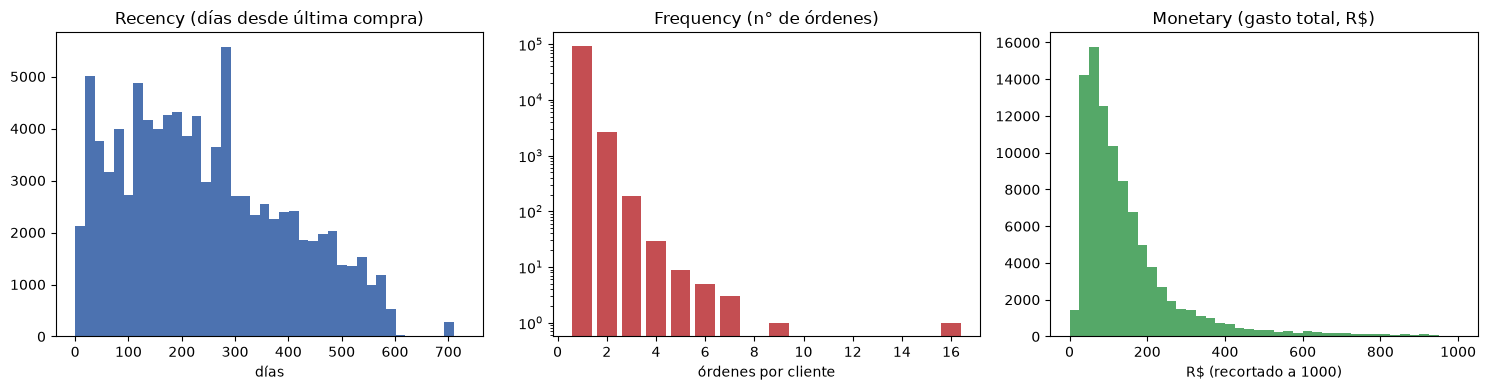

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

axes[0].hist(segmentos["recency_dias"], bins=40, color="#4C72B0")
axes[0].set_title("Recency (días desde última compra)")
axes[0].set_xlabel("días")

axes[1].bar(dist_f.index, dist_f.values, color="#C44E52")
axes[1].set_title("Frequency (n° de órdenes)")
axes[1].set_xlabel("órdenes por cliente")
axes[1].set_yscale("log")       # log: si no, la barra de 1 aplasta todo lo demás

axes[2].hist(segmentos["monetary"], bins=40, range=(0, 1000), color="#55A868")
axes[2].set_title("Monetary (gasto total, R$)")
axes[2].set_xlabel("R$ (recortado a 1000)")

plt.tight_layout()   # que los 3 títulos no se pisen
plt.show()

**Lectura visual — R/F/M:**

- **Frequency (gráfico del medio):** la barra de "1 orden" domina de tal forma que el resto casi no se ve; recién con **eje logarítmico** aparecen las de 2+. Visualmente la recompra es marginal. El conteo de la celda anterior le pone número (92.102 de 94.990 compran una sola vez; el resto, unos pocos miles, repite). Por eso F **no se cuartiliza** y se usa como bandera binaria `repite`.
- **Recency (izquierda):** distribución ancha y repartida, sin un pico único — coherente con un negocio de adquisición constante más que de recompra.
- **Monetary (derecha):** fuerte sesgo a la derecha, con cola larga de tickets altos (recortada a 1.000 solo en el dibujo). Junto con R, es donde hay dispersión para cuartilizar.

## 3. Segmentos: clientes vs. valor

### 3.1 Tabla resumen

In [6]:
# tabla resumen: Una fila por segmento, generada desde el DataFrame
resumen = (
    segmentos
    .groupby("segmento")
    .agg(
        clientes=("customer_unique_id", "count"),   # cuántas personas
        revenue=("monetary", "sum"),    # gasto total del segmento
        gasto_prom=("monetary", "mean"),    # gasto promedio por cliente
    )
    .reset_index()
)

# % sobre el total (el "share" del segmento)
resumen["pct_clientes"] = resumen["clientes"] / resumen["clientes"].sum() * 100
resumen["pct_revenue"] = resumen["revenue"] / resumen["revenue"].sum() * 100

# ordenar por revenue (el que más plata trae)
resumen = (
    resumen
    .sort_values("revenue", ascending=False)
    .reset_index(drop=True)
    [["segmento","clientes","pct_clientes","revenue","pct_revenue","gasto_prom"]]
)

resumen.round(2)

,segmento,clientes,pct_clientes,revenue,pct_revenue,gasto_prom
0,Prometedores,22836,24.04,5979531.46,38.00,261.85
1,Dormidos alto valor,22121,23.29,5872184.76,37.32,265.46
2,Hibernando,24068,25.34,1537344.76,9.77,63.88
3,Recientes,23077,24.29,1456207.55,9.25,63.10
4,Campeones,2537,2.67,861306.98,5.47,339.50
5,Leales,351,0.37,28951.52,0.18,82.48


### 3.2 Gráfico: % clientes vs % revenue

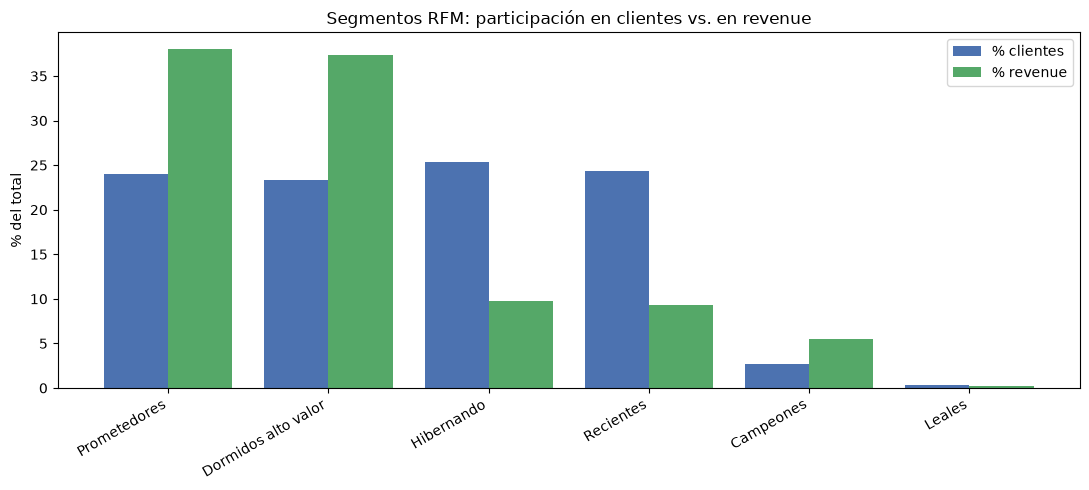

In [7]:
orden = resumen["segmento"].tolist()    # mismo orden que la tabla (por revenue)
x = range(len(orden))
w = 0.4

fig, ax = plt.subplots(figsize=(11,5))

ax.bar([i - w/2 for i in x], resumen["pct_clientes"], width=w, label="% clientes", color="#4C72B0")

ax.bar([i + w/2 for i in x], resumen["pct_revenue"], width=w, label="% revenue", color="#55A868")

ax.set_xticks(list(x))
ax.set_xticklabels(orden, rotation=30, ha="right")
ax.set_ylabel("% del total")
ax.set_title("Segmentos RFM: participación en clientes vs. en revenue")
ax.legend()
plt.tight_layout()
plt.show()

**Lectura visual — segmentos:**

- El gráfico contrapone, por segmento, la barra de **% de clientes** (azul) contra la de **% de revenue** (verde). Salta a la vista la **desconexión entre volumen y valor**:
  - En **Prometedores** y **Dormidos alto valor** la verde supera con claridad a la azul (pocos clientes, mucho revenue) — son las dos barras verdes más altas del gráfico.
  - En **Hibernando** y **Recientes** es al revés: la azul supera a la verde (mucho volumen, poco revenue).
  - **Campeones** y **Leales** son franjas mínimas en ambas barras.
- La tabla de arriba pone los números detrás: Prometedores y Dormidos alto valor tienen el mayor % de revenue y el gasto promedio por cliente más alto (~R$ 260+), frente a ~R$ 63 de Hibernando y Recientes. Campeones + Leales (2.537 + 351) son los recompradores de la T4.
- La palanca accionable son los **Prometedores** (alto valor, recientes, compra única): de la T4 sabemos que el que recompra vuelve en los primeros 30 días → segmento y ventana donde empujar la 2ª compra rinde más.

## 4. Pareto de revenue

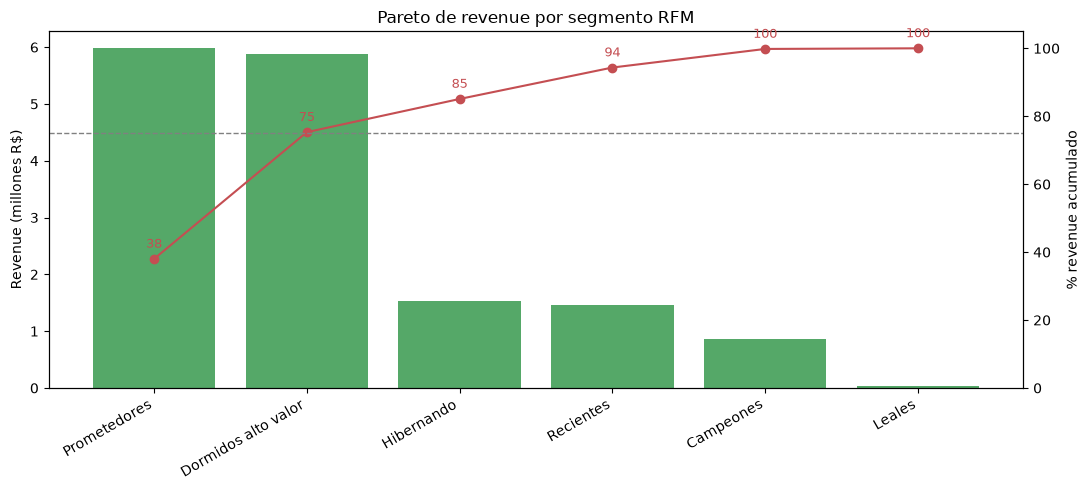

In [8]:
# Pareto: barras de revenue por segmento + línea de % acumulado
pareto = resumen.copy().reset_index(drop=True)
pareto["pct_revenue_acum"] = pareto["pct_revenue"].cumsum()

x = range(len(pareto))
fig, ax1 = plt.subplots(figsize=(11, 5))

# Eje izquierdo: revenue por segmento (en millones)
ax1.bar(x, pareto["revenue"] / 1e6, color="#55A868")
ax1.set_ylabel("Revenue (millones R$)")
ax1.set_xticks(list(x))
ax1.set_xticklabels(pareto["segmento"], rotation=30, ha="right")

# Eje derecho: % de revenue acumulado (la curva de Pareto)
ax2 = ax1.twinx()
ax2.plot(x, pareto["pct_revenue_acum"], color="#C44E52", marker="o")
ax2.set_ylabel("% revenue acumulado")
ax2.set_ylim(0, 105)
ax2.axhline(75, color="gray",linestyle="--", linewidth=1)   # línea de referencia en 75%

# etiquetar cada punto acumulado
for xi, y in zip(x, pareto["pct_revenue_acum"]):
    ax2.annotate(f"{y:.0f}", (xi, y), textcoords="offset points",
                 xytext=(0,8), ha="center", fontsize=9, color="#C44E52")
    
ax1.set_title("Pareto de revenue por segmento RFM")
plt.tight_layout()
plt.show()

**Lectura visual — Pareto:**

- Las barras de revenue por segmento **caen abruptamente**: las dos primeras (Prometedores y Dormidos alto valor) son de altura parecida y mucho más altas que el resto.
- La curva de acumulado (línea roja, eje derecho) lo confirma: el gráfico anota **~38%** en el primer segmento y llega a **~75%** en el segundo, cruzando la línea de referencia punteada. Es decir, **con solo 2 de los 6 segmentos ya se junta cerca de tres cuartos del revenue** — el patrón clásico de Pareto (pocos concentran mucho).
- Del tercer segmento en adelante la curva se aplana: los 4 restantes reparten el cuarto que queda.
- Implicancia: el esfuerzo no rinde repartido parejo entre los 6 segmentos; el foco está donde se acumula el revenue y hay margen de acción — los **Prometedores**.

## 5. Cruce cohorte × segmento

### 5.1 Matriz cohorte × segmento

In [9]:
# cohorte = mes de 1a compra por cliente, desde base_analitica
cohortes = q("""
    select
        customer_unique_id,
        strftime(min(fecha_compra), '%Y-%m') as cohorte
    from marts.base_analitica
    group by customer_unique_id
""")

In [10]:
cohortes.head(5)

,customer_unique_id,cohorte
0,7973a6ba9c81ecaeb3d628c33c7c7c48,2017-09
1,c89cf1a054b60f1d893617b0b1a140d7,2017-11
2,344fecfc1b158f40bd95550e62547fda,2018-02
3,fb20bf5c01fbc8bb8ab3ec1e4104c9d5,2018-01
4,e20247a9f1cdb71d4415f2a0903212f9,2018-03


Unimos cada cliente con su cohorte (mes de 1ª compra) y normalizamos la matriz por fila.

In [11]:
# Unir cohorte con su segmento RFM
cs = segmentos.merge(cohortes, on="customer_unique_id", how="inner")

# recorte de cohortes 2016 (muy chicas -> ruido), mismo criterio que S2
cs = cs[cs["cohorte"] >= "2017-01"]

# matriz cohorte x segmento (conteo de clientes)
orden_seg = ["Campeones", "Leales", "Prometedores",
             "Dormidos alto valor", "Recientes", "Hibernando"]

mat = cs.pivot_table(index="cohorte", columns="segmento",
                    values="customer_unique_id", aggfunc="count", fill_value=0)

mat = mat[[c for c in orden_seg if c in mat.columns]]   # Ordenar de alto a bajo valor

# normalizar por fila -> composición % dentro de cada cohorte
mat_pct = mat.div(mat.sum(axis=1), axis=0) * 100
mat_pct.round(1)

segmento,Campeones,Leales,Prometedores,Dormidos alto valor,Recientes,Hibernando
cohorte,,,,,,
2017-01,6.4,0.9,0.0,47.1,0.0,45.6
2017-02,3.5,0.7,0.0,47.3,0.0,48.6
2017-03,4.2,0.9,0.0,45.0,0.0,50.0
2017-04,3.9,0.6,0.0,46.1,0.0,49.3
2017-05,4.7,0.6,0.0,45.0,0.0,49.6
2017-06,4.9,0.5,0.0,43.6,0.0,51.0
2017-07,4.3,0.4,0.0,44.6,0.0,50.7
2017-08,4.0,0.7,0.0,43.8,0.0,51.5
2017-09,4.3,0.4,0.0,45.6,0.0,49.8


### 5.2 Gráfico apilado 100%

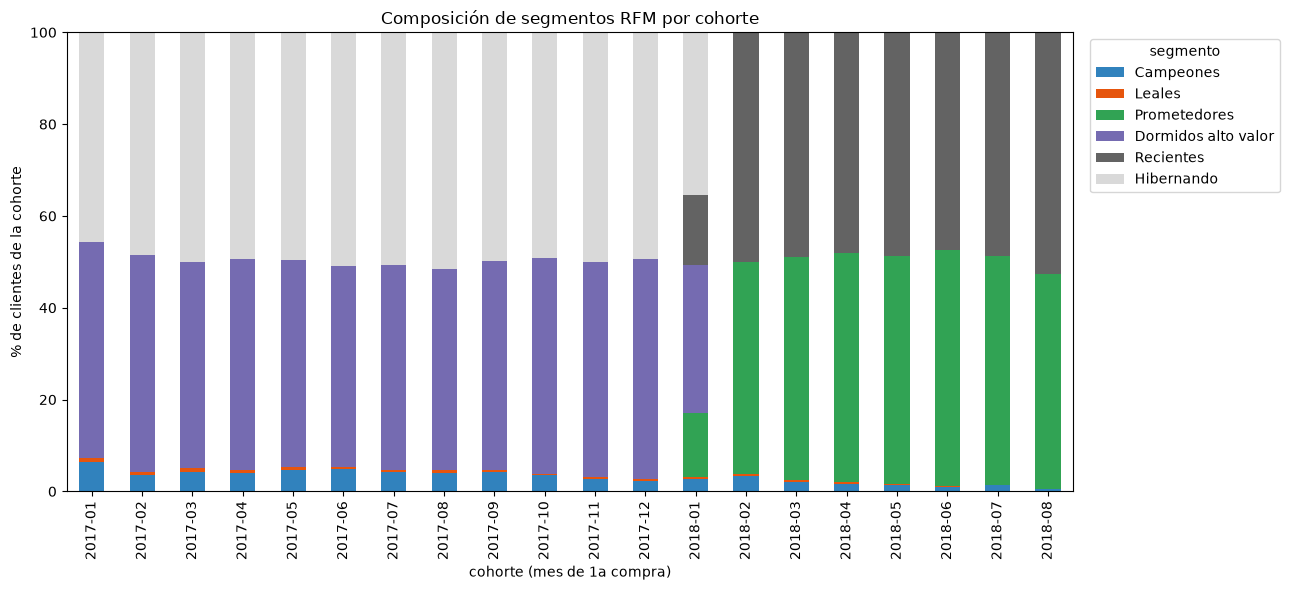

In [12]:
ax = mat_pct.plot(kind="bar", stacked=True, figsize=(13, 6), colormap="tab20c")
ax.set_ylabel("% de clientes de la cohorte")
ax.set_xlabel("cohorte (mes de 1a compra)")
ax.set_title("Composición de segmentos RFM por cohorte")
ax.legend(title="segmento", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Lectura visual — cohorte × segmento:**

- El apilado 100% muestra un **giro brusco** (no gradual): en las cohortes de **2017** (izquierda) casi no hay franja de Prometedores ni Recientes; dominan Dormidos alto valor e Hibernando. Desde **2018** (derecha) se invierte: desaparece la franja de Dormidos alto valor y aparecen las de Prometedores y Recientes.
- **Ese giro es mecánico, no un hallazgo:** para la gran mayoría que compra una sola vez, la Recency *es* su fecha de compra, y el `ntile(4)` corta la línea de tiempo en un umbral fijo respecto de `FECHA_CORTE`. El eje R solo **renombra** al mismo cliente de "Dormido alto valor" (cohorte vieja) a "Prometedor" (cohorte nueva) — tiempo mirándose a sí mismo.
- **El hallazgo real está en el eje que no depende del tiempo (valor):** Prometedores y Dormidos alto valor van contiguos en el apilado, así que su **franja combinada de alto valor** se lee como un bloque — y ese bloque mantiene una **altura pareja de cohorte a cohorte**. La calidad del cliente que capta Olist es **estable en el tiempo**: la adquisición no mejora ni se degrada.
- Matiz de ventana de observación: la franja de **Campeones** (base del apilado) se **adelgaza** en las cohortes nuevas, porque todavía no tuvieron tiempo de hacer su 2ª compra — mismo efecto de truncamiento que el LTV de la S2 (T3).
- **Cierre S2 × S3:** la cohorte reordena *quién es reciente*, pero no *cuánto vale*; el valor es una propiedad estable del cliente desde su 1ª compra (coherente con la T3: casi todo el valor del cliente está en su primera compra).